In [1]:
import pandas as pd
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt 
import yaml
import os
import sys

plt.style.use("~/evanstyle.mplstyle") #replace with your own or comment


In [2]:
redfile_sig = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/temp/combined.p"
df_sig = pickle.load(open(redfile_sig, "rb"))[0]

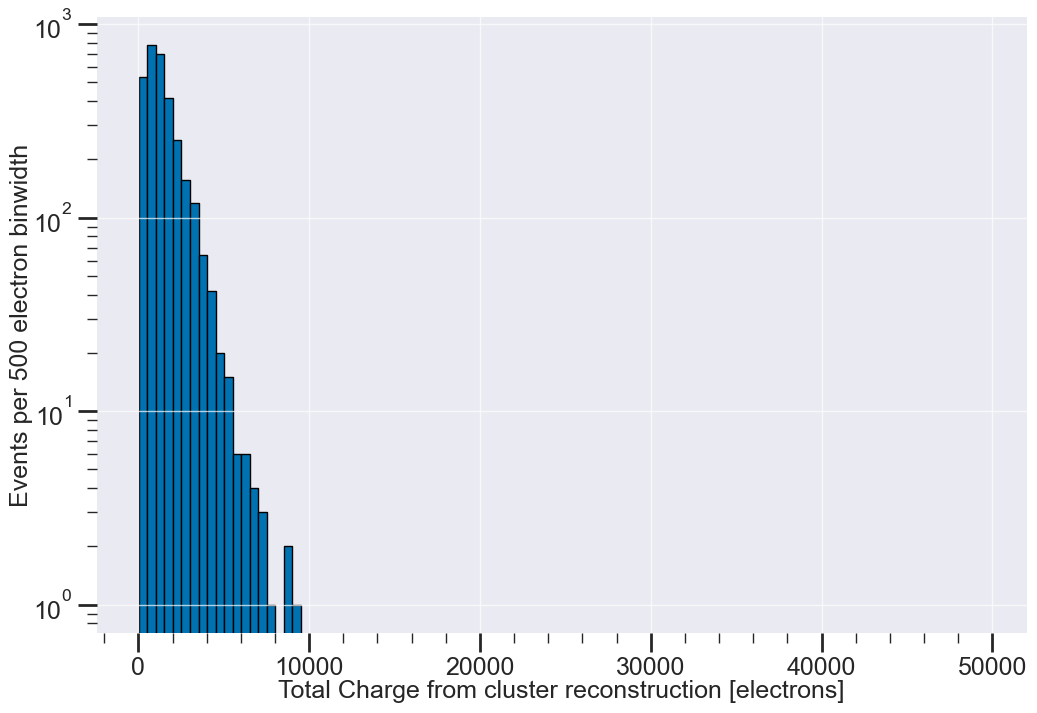

In [3]:
#example of how to slice for a basic quantity in the reducedquantities list. 

#most of the time you'll start by ignoring events with "None" (or accidentally NaN's, trying not to have those in the first place)
mask = (df_sig["total_charge"] != None)
hs = df_sig["total_charge"][mask]
#i like to control binwidth manually, which is why I use a separate "hs" variable
binwidth = 500 #electrons
bins = np.arange(np.min(hs), 50000, binwidth)
fig, ax = plt.subplots()
ax.hist(hs, bins=bins, label="Source inserted")


ax.set_xlabel("Total Charge from cluster reconstruction [electrons]")
ax.set_ylabel("Events per {:.0f} electron binwidth".format(binwidth))
ax.set_yscale('log')
plt.show()


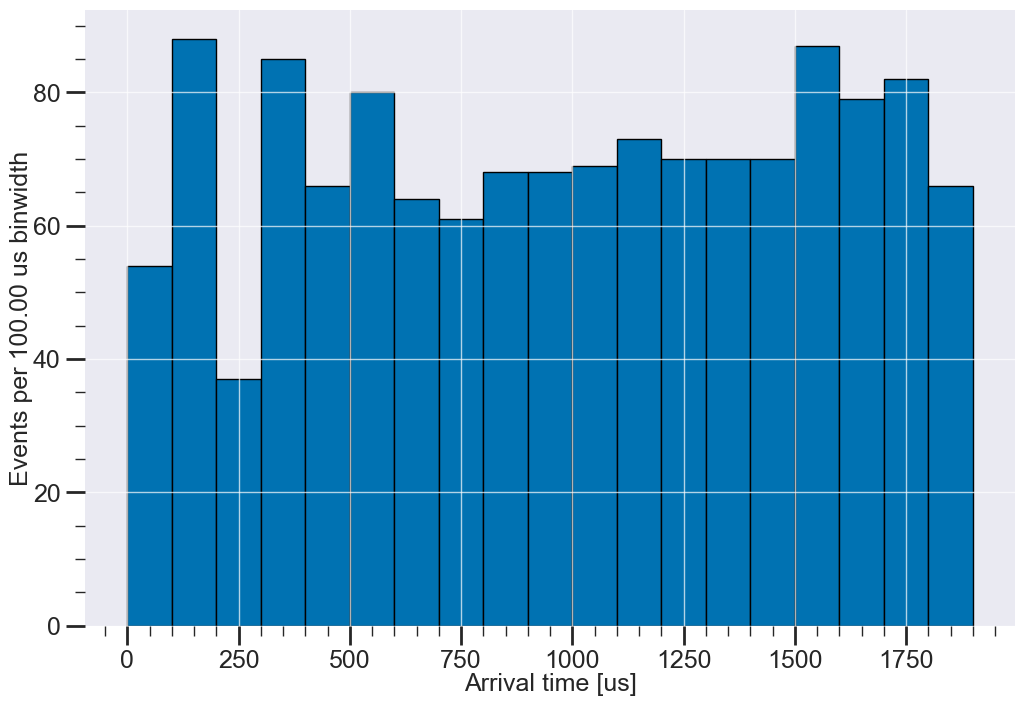

In [6]:
hs = df_sig["t"]
binwidth = 100 #us
bins = np.arange(0, 2000, binwidth)
fig, ax = plt.subplots()
ax.hist(hs, bins=bins)
ax.set_xlabel("Arrival time [us]")
ax.set_ylabel("Events per {:.2f} us binwidth".format(binwidth))
plt.show()

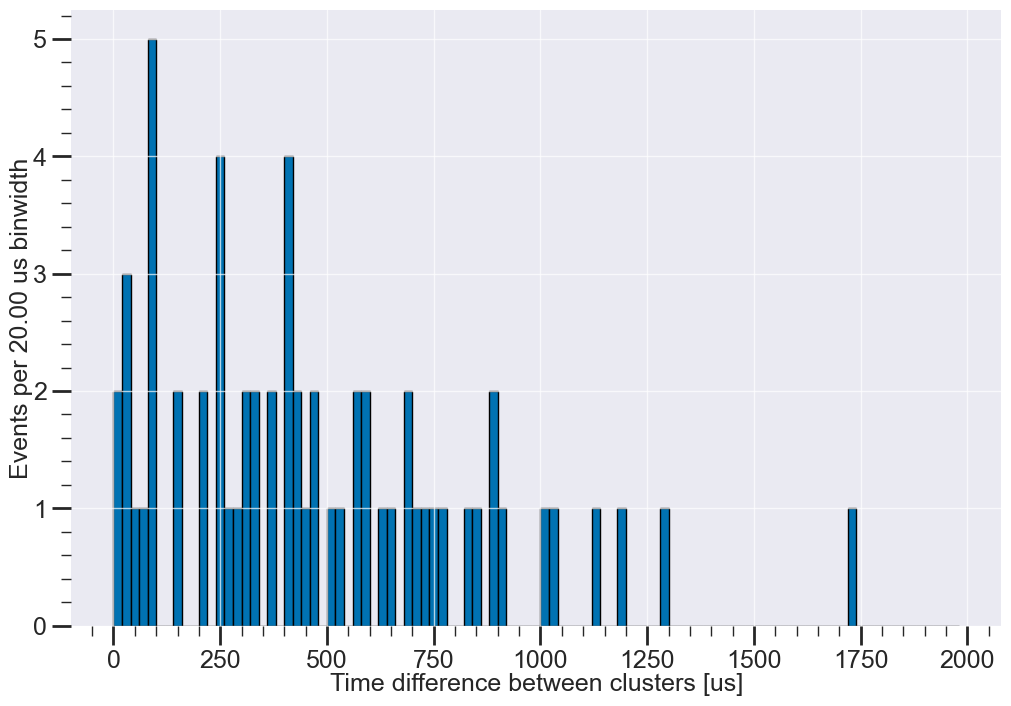

In [12]:
mask = (df_sig["total_charge"] != None) & (df_sig["multi_site"] == 1)
dts = []
for i, row in df_sig[mask].iterrows():
    ts = []
    for clust in row["clusters"]:
        if(clust["t_arrival"] == None): 
            continue
        ts.append(clust["t_arrival"])
    
    if(len(ts) == 1):
        continue
    elif(len(ts) == 2):
        dts.append(np.abs(ts[1] - ts[0]))
    else:
        for i in range(len(ts)):
            for j in range(i+1, len(ts)):
                dts.append(np.abs(ts[j] - ts[i]))


hs = dts
binwidth = 20 #us
bins = np.arange(0, 2000, binwidth)
fig, ax = plt.subplots()
ax.hist(hs, bins=bins)
ax.set_xlabel("Time difference between clusters [us]")
ax.set_ylabel("Events per {:.2f} us binwidth".format(binwidth))
plt.show()

   